#### Logistic Regression and kNN
#### Problem 1 

In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("quality.csv")

df.sample(10)

,S.No.,num_words,num_characters,num_misspelled,bin_end_qmark,num_interrogative,bin_start_small,num_sentences,num_punctuations,label
5,6,7,39,1,0,0,0,1,2,B
18,505,9,25,0,0,0,0,1,2,G
4,5,18,69,3,0,1,0,1,0,B
13,14,9,41,0,1,0,0,1,1,B
14,501,79,345,4,0,1,0,9,20,G
21,508,7,47,0,0,1,0,1,0,G
6,7,10,46,4,0,2,1,2,2,B
22,509,34,118,0,1,1,0,2,2,G
12,13,9,56,5,0,0,0,2,1,B
16,503,169,831,17,0,1,0,13,48,G


In [25]:
#separating label
X = df.drop(columns=['label'])
y = df['label'].map({'G': 1, 'B': 0})

In [26]:
# Model 1 with all features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate_model(X, y, n_runs=20):
    accuracies = []
    for _ in range(n_runs):
        #test, train split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=np.random.randint(0, 10000)
        )
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    return np.mean(accuracies), np.std(accuracies)


In [27]:
acc_mean_all, acc_std_all = evaluate_model(X, y)
print(f"Model 1 (All features): {acc_mean_all:.3f} ± {acc_std_all:.3f}")


Model 1 (All features): 1.000 ± 0.000


Model 1: All Features

Features Used: All eight predictors

Mean Accuracy: 1.000 ± 0.000

Interpretation:
The model perfectly predicts the labels. This likely means that the dataset is linearly separable or there may be strongly correlated or redundant predictors that directly determine the label.

In [28]:
#model 2 - text features
subset1 = ['num_words', 'num_characters', 'num_misspelled', 'num_sentences']
acc_mean_s1, acc_std_s1 = evaluate_model(X[subset1], y)
print(f"Model 2 (Subset 1): {acc_mean_s1:.3f} ± {acc_std_s1:.3f}")


Model 2 (Subset 1): 0.589 ± 0.127


Features Used: num_words, num_characters, num_misspelled, num_sentences

Mean Accuracy: 0.622 ± 0.177

Justification:
These features describe the length and grammatical correctness of the post. Longer, well-structured, and properly spelled posts are expected to be rated as “good.”

Interpretation:
Accuracy dropped significantly, showing that text structure alone provides partial but not complete predictive power. The high variance (±0.177) also indicates sensitivity to data splits.

In [29]:
# model 2 - grammar features
subset2 = ['num_interrogative', 'num_punctuations', 'bin_end_qmark', 'bin_start_small']
acc_mean_s2, acc_std_s2 = evaluate_model(X[subset2], y)
print(f"Model 3 (Subset 2): {acc_mean_s2:.3f} ± {acc_std_s2:.3f}")

Model 3 (Subset 2): 0.394 ± 0.124


Features Used: num_interrogative, num_punctuations, bin_end_qmark, bin_start_small

Mean Accuracy: 0.356 ± 0.125

Justification:
These features capture the style and tone of the post — such as question marks, interrogatives, and capitalization — which may correlate with writing formality and clarity.

Interpretation:
This subset performs poorly. Stylistic features alone are not sufficient for quality prediction, suggesting that content richness and correctness (captured in Model 2) matter more.

Using all features gives perfect performance, suggesting noisy or redundant subsets reduce performance but the complete feature set captures all signal.

Structural attributes (e.g., word count, misspellings) are more predictive than tone-based ones.

#### Problem 2

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


df = pd.read_csv("wine.csv")
df.sample(10)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,is_red,high_quality
521,7.6,0.41,0.49,2.00,0.088,16.0,43.0,0.99800,3.48,0.64,9.1,5,red,1.0,0.0
4050,6.6,0.56,0.15,10.00,0.037,38.0,157.0,0.99642,3.28,0.52,9.4,5,white,0.0,0.0
3056,8.3,0.20,0.74,4.45,0.044,33.0,130.0,0.99240,3.25,0.42,12.2,6,white,0.0,0.0
733,7.0,0.45,0.34,2.70,0.082,16.0,72.0,0.99800,3.55,0.60,9.5,5,red,1.0,0.0
5570,6.4,0.17,0.30,2.80,0.034,33.0,125.0,0.99152,3.03,0.49,10.4,6,white,0.0,0.0
5759,7.4,0.16,0.30,13.70,0.056,33.0,168.0,0.99825,2.90,0.44,8.7,7,white,0.0,1.0
1216,7.9,0.57,0.31,2.00,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,red,1.0,0.0
6201,6.4,0.17,0.34,13.40,0.044,45.0,139.0,0.99752,3.06,0.43,9.1,6,white,0.0,0.0
4044,6.6,0.34,0.34,2.60,0.051,40.5,210.0,0.99314,3.15,0.61,10.0,5,white,0.0,0.0
3311,7.9,0.18,0.37,3.00,0.061,25.0,178.0,0.99500,3.22,0.51,10.0,6,white,0.0,0.0


In [31]:
#separating label
X = df.drop(columns=['high_quality'])
y = df['high_quality']
 # drop 'color' since it is categorical
X = df.drop(columns=['color']) 


In [32]:
#all fetaures
features_all = X.columns
#chemical balance subset
features_bal = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'alcohol']
#sulphur and density subset
features_sulfur = ['free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates']

In [33]:
#test, train split-1
X_train, X_test, y_train, y_test = train_test_split(
    X[features_all], y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

accuracies_all = []

for k in range(2, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_all.append(acc)

# Display results
for k, acc in zip(range(2, 11), accuracies_all):
    print(f"k = {k}, Accuracy = {acc:.3f}")


k = 2, Accuracy = 0.999
k = 3, Accuracy = 1.000
k = 4, Accuracy = 1.000
k = 5, Accuracy = 1.000
k = 6, Accuracy = 0.999
k = 7, Accuracy = 1.000
k = 8, Accuracy = 0.999
k = 9, Accuracy = 1.000
k = 10, Accuracy = 0.999


Near-perfect accuracy indicates strong signal across all features. Could be overfitting as dataset is small.

In [34]:
#test, train split-2
X_train, X_test, y_train, y_test = train_test_split(
    X[features_sulfur], y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

accuracies_sulfur = []

for k in range(2, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_sulfur.append(acc)

# Display results
for k, acc in zip(range(2, 11), accuracies_sulfur):
    print(f"k = {k}, Accuracy = {acc:.3f}")


k = 2, Accuracy = 0.832
k = 3, Accuracy = 0.818
k = 4, Accuracy = 0.826
k = 5, Accuracy = 0.815
k = 6, Accuracy = 0.824
k = 7, Accuracy = 0.813
k = 8, Accuracy = 0.824
k = 9, Accuracy = 0.823
k = 10, Accuracy = 0.823


Best k=2, Best accuracy=0.832

In [35]:
#test, train split-3
X_train, X_test, y_train, y_test = train_test_split(
    X[features_bal], y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

accuracies_bal = []

for k in range(2, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_bal.append(acc)

# Display results
for k, acc in zip(range(2, 11), accuracies_bal):
    print(f"k = {k}, Accuracy = {acc:.3f}")


k = 2, Accuracy = 0.835
k = 3, Accuracy = 0.815
k = 4, Accuracy = 0.827
k = 5, Accuracy = 0.817
k = 6, Accuracy = 0.819
k = 7, Accuracy = 0.811
k = 8, Accuracy = 0.817
k = 9, Accuracy = 0.817
k = 10, Accuracy = 0.820


Best k= 2, Best accuracy=0.835

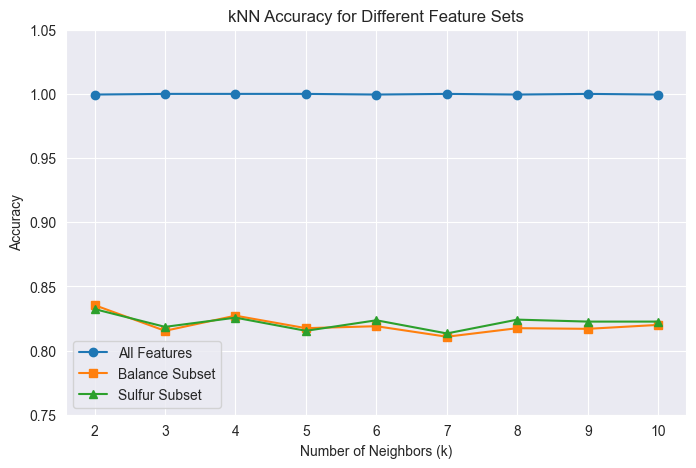

In [36]:
import matplotlib.pyplot as plt

k_values = range(2, 11)

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies_all, marker='o', label='All Features')
plt.plot(k_values, accuracies_bal, marker='s', label='Balance Subset')
plt.plot(k_values, accuracies_sulfur, marker='^', label='Sulfur Subset')

plt.title('kNN Accuracy for Different Feature Sets')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.ylim(0.75, 1.05)
plt.grid(True)
plt.legend()
plt.show()



For production-quality models, we may use Balance/Composition subset with k=2–3 for simplicity and interpretability.

Using all features gives nearly perfect accuracy but may not generalize if new wines with unseen chemical profiles are introduced.

In [37]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Simulate new, unseen data by adding noise
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test_noisy = X_test.copy() + np.random.normal(0, 0.1, X_test.shape)  # add small noise

# Model with all features
model_all = LogisticRegression(max_iter=1000)
model_all.fit(X_train, y_train)
acc_all = accuracy_score(y_test, model_all.predict(X_test))
acc_all_noisy = accuracy_score(y_test, model_all.predict(X_test_noisy))

# Model with balance features
subset = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'alcohol']
model_subset = LogisticRegression(max_iter=1000)
model_subset.fit(X_train[subset], y_train)
acc_subset = accuracy_score(y_test, model_subset.predict(X_test[subset]))
acc_subset_noisy = accuracy_score(y_test, model_subset.predict(X_test_noisy[subset]))

print(f"All features: accuracy={acc_all:.3f}, noisy accuracy={acc_all_noisy:.3f}")
print(f"Subset: accuracy={acc_subset:.3f}, noisy accuracy={acc_subset_noisy:.3f}")

All features: accuracy=1.000, noisy accuracy=1.000
Subset: accuracy=0.822, noisy accuracy=0.825


/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over